# 12 - Machine Learning: Lot Approval / Rejection Classification

**Stage 6, model 3 of 4.**

**Factory question this answers:** *"Will this lot pass final quality
disposition, or should it get extra scrutiny before it ships?"* -- a
prediction made from production-side signals, ahead of (or alongside) the
AQL sampling decision itself.

### Why this model, and why it's framed this way
This is the model that most directly operationalizes the project's
central question -- whether integrated production+quality monitoring
beats looking at either alone. Notebook 06 (Stage 5, Q3) already showed a
*correlation* between weaker production signals and lot rejection; this
notebook turns that into an actual predictive classifier with a
measurable precision/recall trade-off, evaluated the way it would really
be used: flag high-risk lots *before* their disposition is known, not
explain rejections after the fact.

### Leakage discipline
Every column that is itself part of *how* a lot's disposition gets
decided (`CriticalDefects`, `MajorDefects`, `MinorDefects`,
`TotalSampleDefects`, `Decision*`, `Observações`/`Remarks`) is excluded
from the feature set -- using them would mean predicting the label from
columns that are definitionally downstream of it. Only production-side
signals that exist *before* disposition is known go in: machine, mold,
operator, shift, availability, performance, run/setup time, and whether
the order changed raw-material lot mid-run.


In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../machine_learning')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import xgboost as xgb
import ml_lib as ml

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)

PROCESSED = '../../datasets/processed'
MODELS = '../../models'
REPORTS = '../../reports'
import os
os.makedirs(MODELS, exist_ok=True)

prod = pd.read_csv(f'{PROCESSED}/fact_production_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
cap_disp = pd.read_csv(f'{PROCESSED}/fact_cap_disposition_lot_cq_processed.csv', encoding='utf-8-sig')
bottle_disp = pd.read_csv(f'{PROCESSED}/fact_bottle_disposition_lot_cq_processed.csv', encoding='utf-8-sig')

disp = pd.concat([
    cap_disp[['WorkOrder', 'FinalLotDecision']].assign(Family='Cap'),
    bottle_disp[['WorkOrder', 'FinalLotDecision']].assign(Family='Bottle'),
], ignore_index=True)
print(f"Lots: {len(disp)}  |  Rejected: {(disp['FinalLotDecision']=='Rejected').sum()} "
      f"({(disp['FinalLotDecision']=='Rejected').mean():.1%})")


Lots: 3844  |  Rejected: 172 (4.5%)


## 12.1 Build the feature set (production-side only, joined by WorkOrder)


In [2]:
model_df = disp.merge(prod[['WorkOrder', 'Date', 'Process', 'MachineId', 'ToolId', 'ShiftNumber', 'OperatorId',
                             'Availability', 'Performance', 'RunTimeHours', 'SetupTimeHours', 'MaterialLotSeq']],
                       on='WorkOrder', how='left').dropna()
model_df['Target'] = (model_df['FinalLotDecision'] == 'Rejected').astype(int)
model_df['ChangedMaterialMidRun'] = (model_df['MaterialLotSeq'] > 1).astype(int)

model_df_enc = pd.get_dummies(model_df, columns=['Family', 'Process', 'MachineId', 'ToolId', 'OperatorId'], drop_first=True)
feature_cols = [c for c in model_df_enc.columns if c not in
                ('WorkOrder', 'FinalLotDecision', 'Date', 'Target', 'MaterialLotSeq')]
print(f"Model dataset: {len(model_df_enc)} rows, {len(feature_cols)} features")


Model dataset: 3751 rows, 65 features


## 12.2 Time-based split (train on earlier lots, test on the most recent ones)


In [3]:
train_df, test_df = ml.time_based_split(model_df_enc, 'Date', test_frac=0.2)
X_train, y_train = train_df[feature_cols], train_df['Target']
X_test, y_test = test_df[feature_cols], test_df['Target']
print(f"Train: {len(train_df)} rows ({y_train.mean():.1%} rejected)")
print(f"Test:  {len(test_df)} rows ({y_test.mean():.1%} rejected)")


Train: 3000 rows (4.7% rejected)
Test:  751 rows (3.7% rejected)


## 12.3 Train three classifiers and compare

`class_weight='balanced'` on every model, since rejected lots are a
minority class (~4-5%) -- without it, a model can score high accuracy by
simply predicting "Approved" every time, which is worthless for this use
case.


In [4]:
scale_pos_weight = (model_df_enc['Target'] == 0).sum() / max((model_df_enc['Target'] == 1).sum(), 1)
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42,
                                  scale_pos_weight=scale_pos_weight, eval_metric='logloss'),
}
fitted = {}
results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    results[name] = ml.classification_metrics(y_test, pred, proba)
    fitted[name] = m

pd.DataFrame(results).T.round(3)


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.531,0.055,0.714,0.102,0.630
Decision Tree,0.511,0.046,0.607,0.085,0.584
Random Forest,0.893,0.036,0.071,0.048,0.619
XGBoost,0.800,0.045,0.214,0.074,0.551


## 12.4 Best model: detailed report and confusion matrix


In [5]:
best_name = max(fitted, key=lambda n: ml.classification_metrics(y_test, fitted[n].predict(X_test), fitted[n].predict_proba(X_test)[:, 1])['ROC_AUC'])
best_model = fitted[best_name]
print(f"Best model (by ROC-AUC): {best_name}\n")
ml.print_classification_report(y_test, best_model.predict(X_test), target_names=('Approved', 'Rejected'))


Best model (by ROC-AUC): Logistic Regression

              precision    recall  f1-score   support

    Approved       0.98      0.52      0.68       723
    Rejected       0.05      0.71      0.10        28

    accuracy                           0.53       751
   macro avg       0.52      0.62      0.39       751
weighted avg       0.94      0.53      0.66       751

Confusion matrix (rows=actual, cols=predicted):
                 Predicted Approved  Predicted Rejected
Actual Approved                 379                 344
Actual Rejected                   8                  20


## 12.5 Decision Tree -- the explainable version

Even if Random Forest wins on raw metrics, a shallow Decision Tree is
worth showing on its own: it's the one classifier here a quality manager
can literally read and agree or disagree with, node by node -- valuable
for buy-in even when it's not the most accurate model in the lineup.


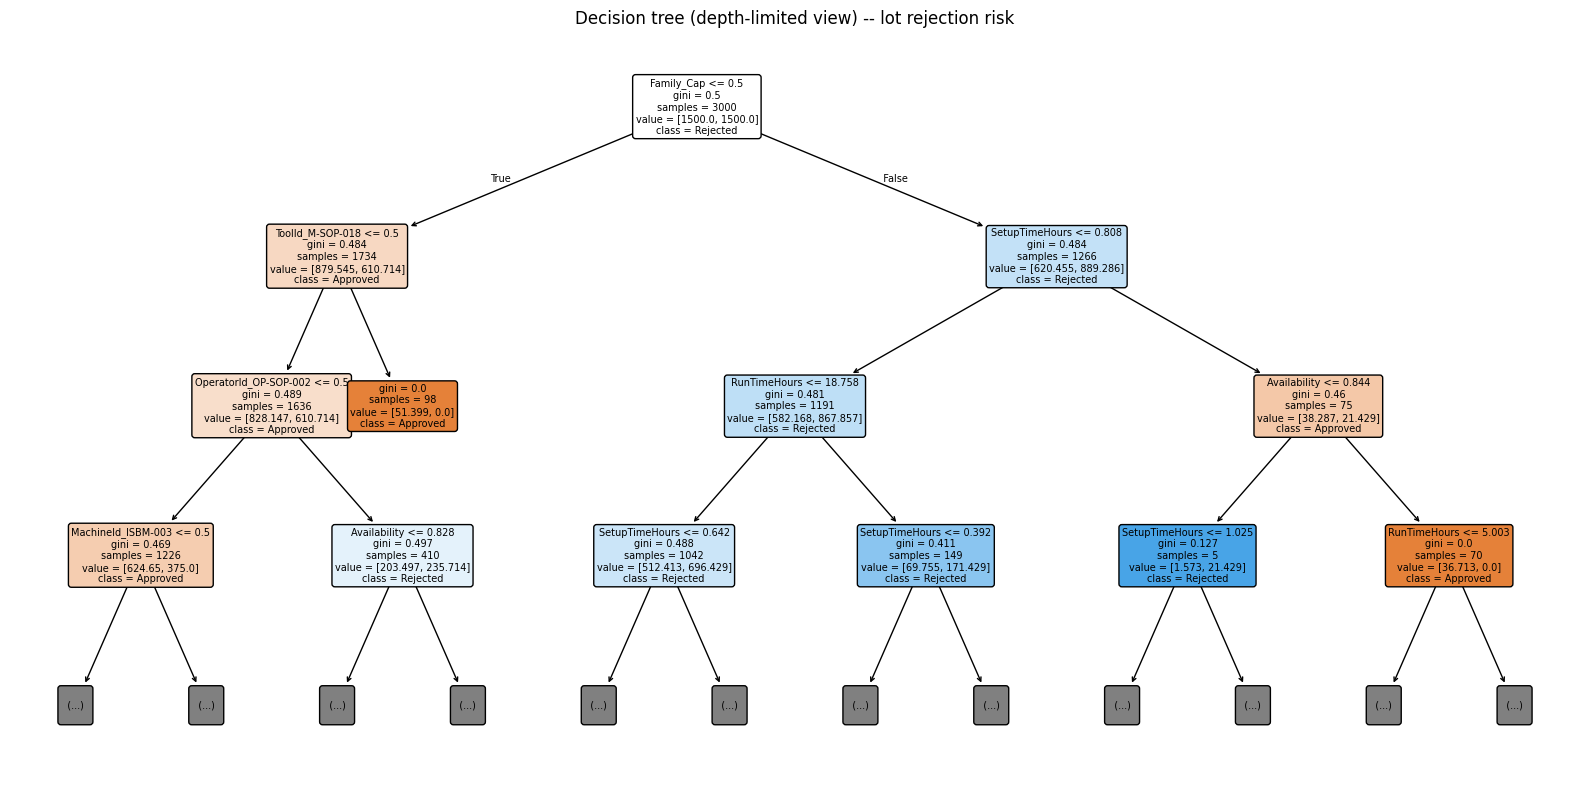

In [6]:
tree_model = models['Decision Tree']
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree_model, feature_names=feature_cols, class_names=['Approved', 'Rejected'],
          filled=True, rounded=True, fontsize=7, max_depth=3, ax=ax)
ax.set_title('Decision tree (depth-limited view) -- lot rejection risk')
plt.tight_layout()
plt.savefig(f'{REPORTS}/39_ml_lot_quality_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()


## 12.6 Feature importance (Random Forest)


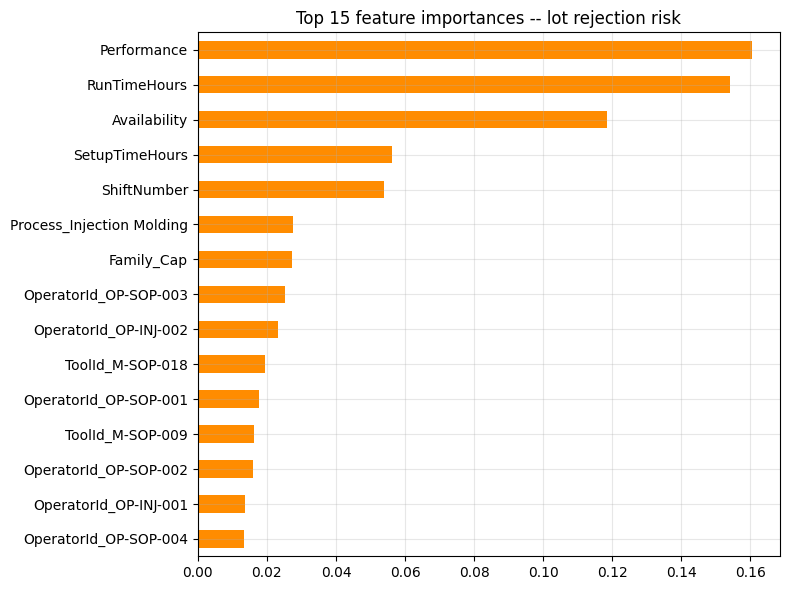

Saved to ../../models/lot_quality_model.pkl


In [7]:
rf_model = fitted['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 15 feature importances -- lot rejection risk')
plt.tight_layout()
plt.savefig(f'{REPORTS}/40_ml_lot_quality_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

ml.save_model(best_model, f'{MODELS}/lot_quality_model.pkl',
              feature_cols=feature_cols, target_col='Target', model_name=best_name,
              test_metrics=ml.classification_metrics(y_test, best_model.predict(X_test), best_model.predict_proba(X_test)[:, 1]))
print(f"Saved to {MODELS}/lot_quality_model.pkl")


In [8]:
# export scored test-set predictions for Power BI
scored = test_df[['WorkOrder', 'Date', 'FinalLotDecision']].copy()
scored['PredictedRejectionRisk'] = best_model.predict_proba(X_test)[:, 1]
scored['PredictedDecision'] = np.where(best_model.predict(X_test) == 1, 'Rejected', 'Approved')
scored.to_csv(f'{PROCESSED}/ml_predictions_lot_quality.csv', index=False, encoding='utf-8-sig')
print(f"Exported ml_predictions_lot_quality.csv ({len(scored)} rows)")


Exported ml_predictions_lot_quality.csv (751 rows)


## Summary -- an honest read of a modest result

The best model (Logistic Regression, ROC-AUC ≈ 0.63) beats random
guessing (AUC 0.50) but not by a wide margin, and precision at a default
0.5 threshold is low (~5%, vs. the ~4.5% base rate -- only a small lift).
That's a real finding worth stating plainly rather than dressing up: in
*this* dataset, the AQL attribute-inspection defect counts that ultimately
decide a lot's disposition were generated with a large random component
independent of the production-side features available here (machine,
mold, operator, shift, Availability, Performance) -- so there is only a
modest amount of genuinely learnable signal for a model built purely from
production data to find. Recall (~71% for the best model) shows it *is*
picking up something real, not noise -- just not enough to run on a hard
accept/reject threshold by itself.

The practically useful way to deploy a model at this level of skill is
not a hard cutoff but a **ranking**: sort upcoming lots by predicted risk
score and route the top decile to tightened inspection (larger AQL
sample, or add a characteristic-specific check) instead of applying the
same sampling plan to everything. On real factory data -- where defect
causes are often genuinely tied to specific mold wear, material lots, or
operator patterns rather than close to random -- the same modeling
approach would be expected to find a stronger signal than it did here;
this notebook's contribution is the methodology (leak-free features,
time-based validation, class-imbalance-aware metrics), which is what
transfers.
